<a href="https://colab.research.google.com/github/Aiswarya-2sathyakumar/ICT_DSA-2026/blob/main/Unsupervised_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Libraries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#for scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
#for PCA
from sklearn.decomposition import PCA

#Clustering
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score

##Data loading

In [57]:
adult_data = pd.read_csv("/content/adult_dataset.csv")

##Data Analysis

In [58]:
adult_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [59]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [60]:
adult_data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


##DATA PREPROCESSING

Duplicate value Analysis

In [61]:
adult_data.duplicated().sum()

np.int64(16)

In [62]:
adult_data.drop_duplicates(inplace= True)

###Missing Values Analysis and Handling

####Numerical columns and Categorical colums

In [63]:
adult_data_num_cols = adult_data.select_dtypes(include =["number"]).columns
adult_data_cat_cols = adult_data.select_dtypes(include =["object"]).columns

In [64]:
adult_data_num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [65]:
adult_data_cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

Replace ? with NaN

In [66]:
print((adult_data == '?').sum())

age                  0
workclass         1763
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1758
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     555
income               0
dtype: int64


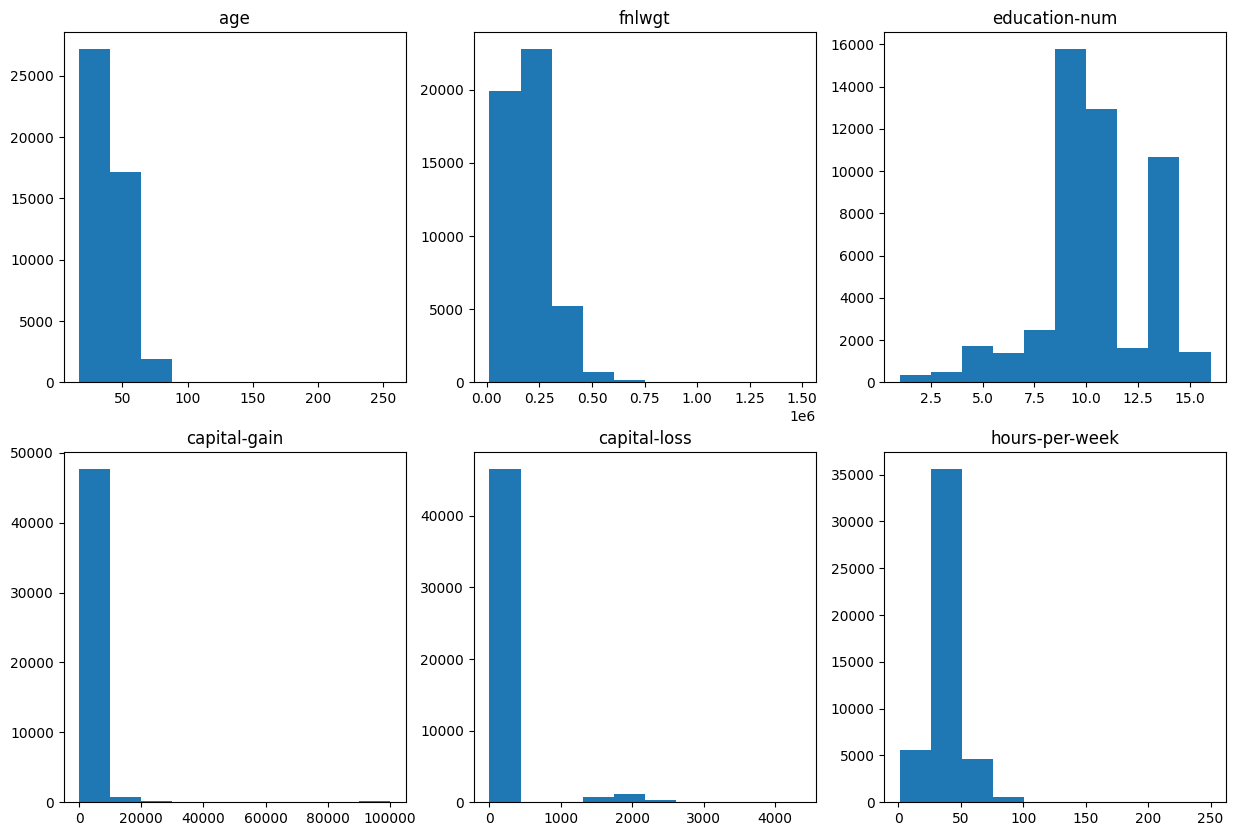

In [67]:
#for numnerical data
plt.figure(figsize=(15,10))
for i,col in enumerate(adult_data_num_cols, 1):
  plt.subplot(2,3,i)
  plt.hist(adult_data[col])
  plt.title(col)

plt.show()

In [68]:
#Here "age " and "hours per week ", both coulms has missing values;
#for "age"
adult_data['age'].fillna(adult_data['age'].median(), inplace=True)

/tmp/ipykernel_1817/2127745977.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['age'].fillna(adult_data['age'].median(), inplace=True)


In [69]:
adult_data['hours-per-week'].fillna(adult_data['hours-per-week'].median(), inplace=True)

/tmp/ipykernel_1817/1608162254.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['hours-per-week'].fillna(adult_data['hours-per-week'].median(), inplace=True)


In [70]:
#After
adult_data.isna().sum()

,0
age,0
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [71]:
adult_data_cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

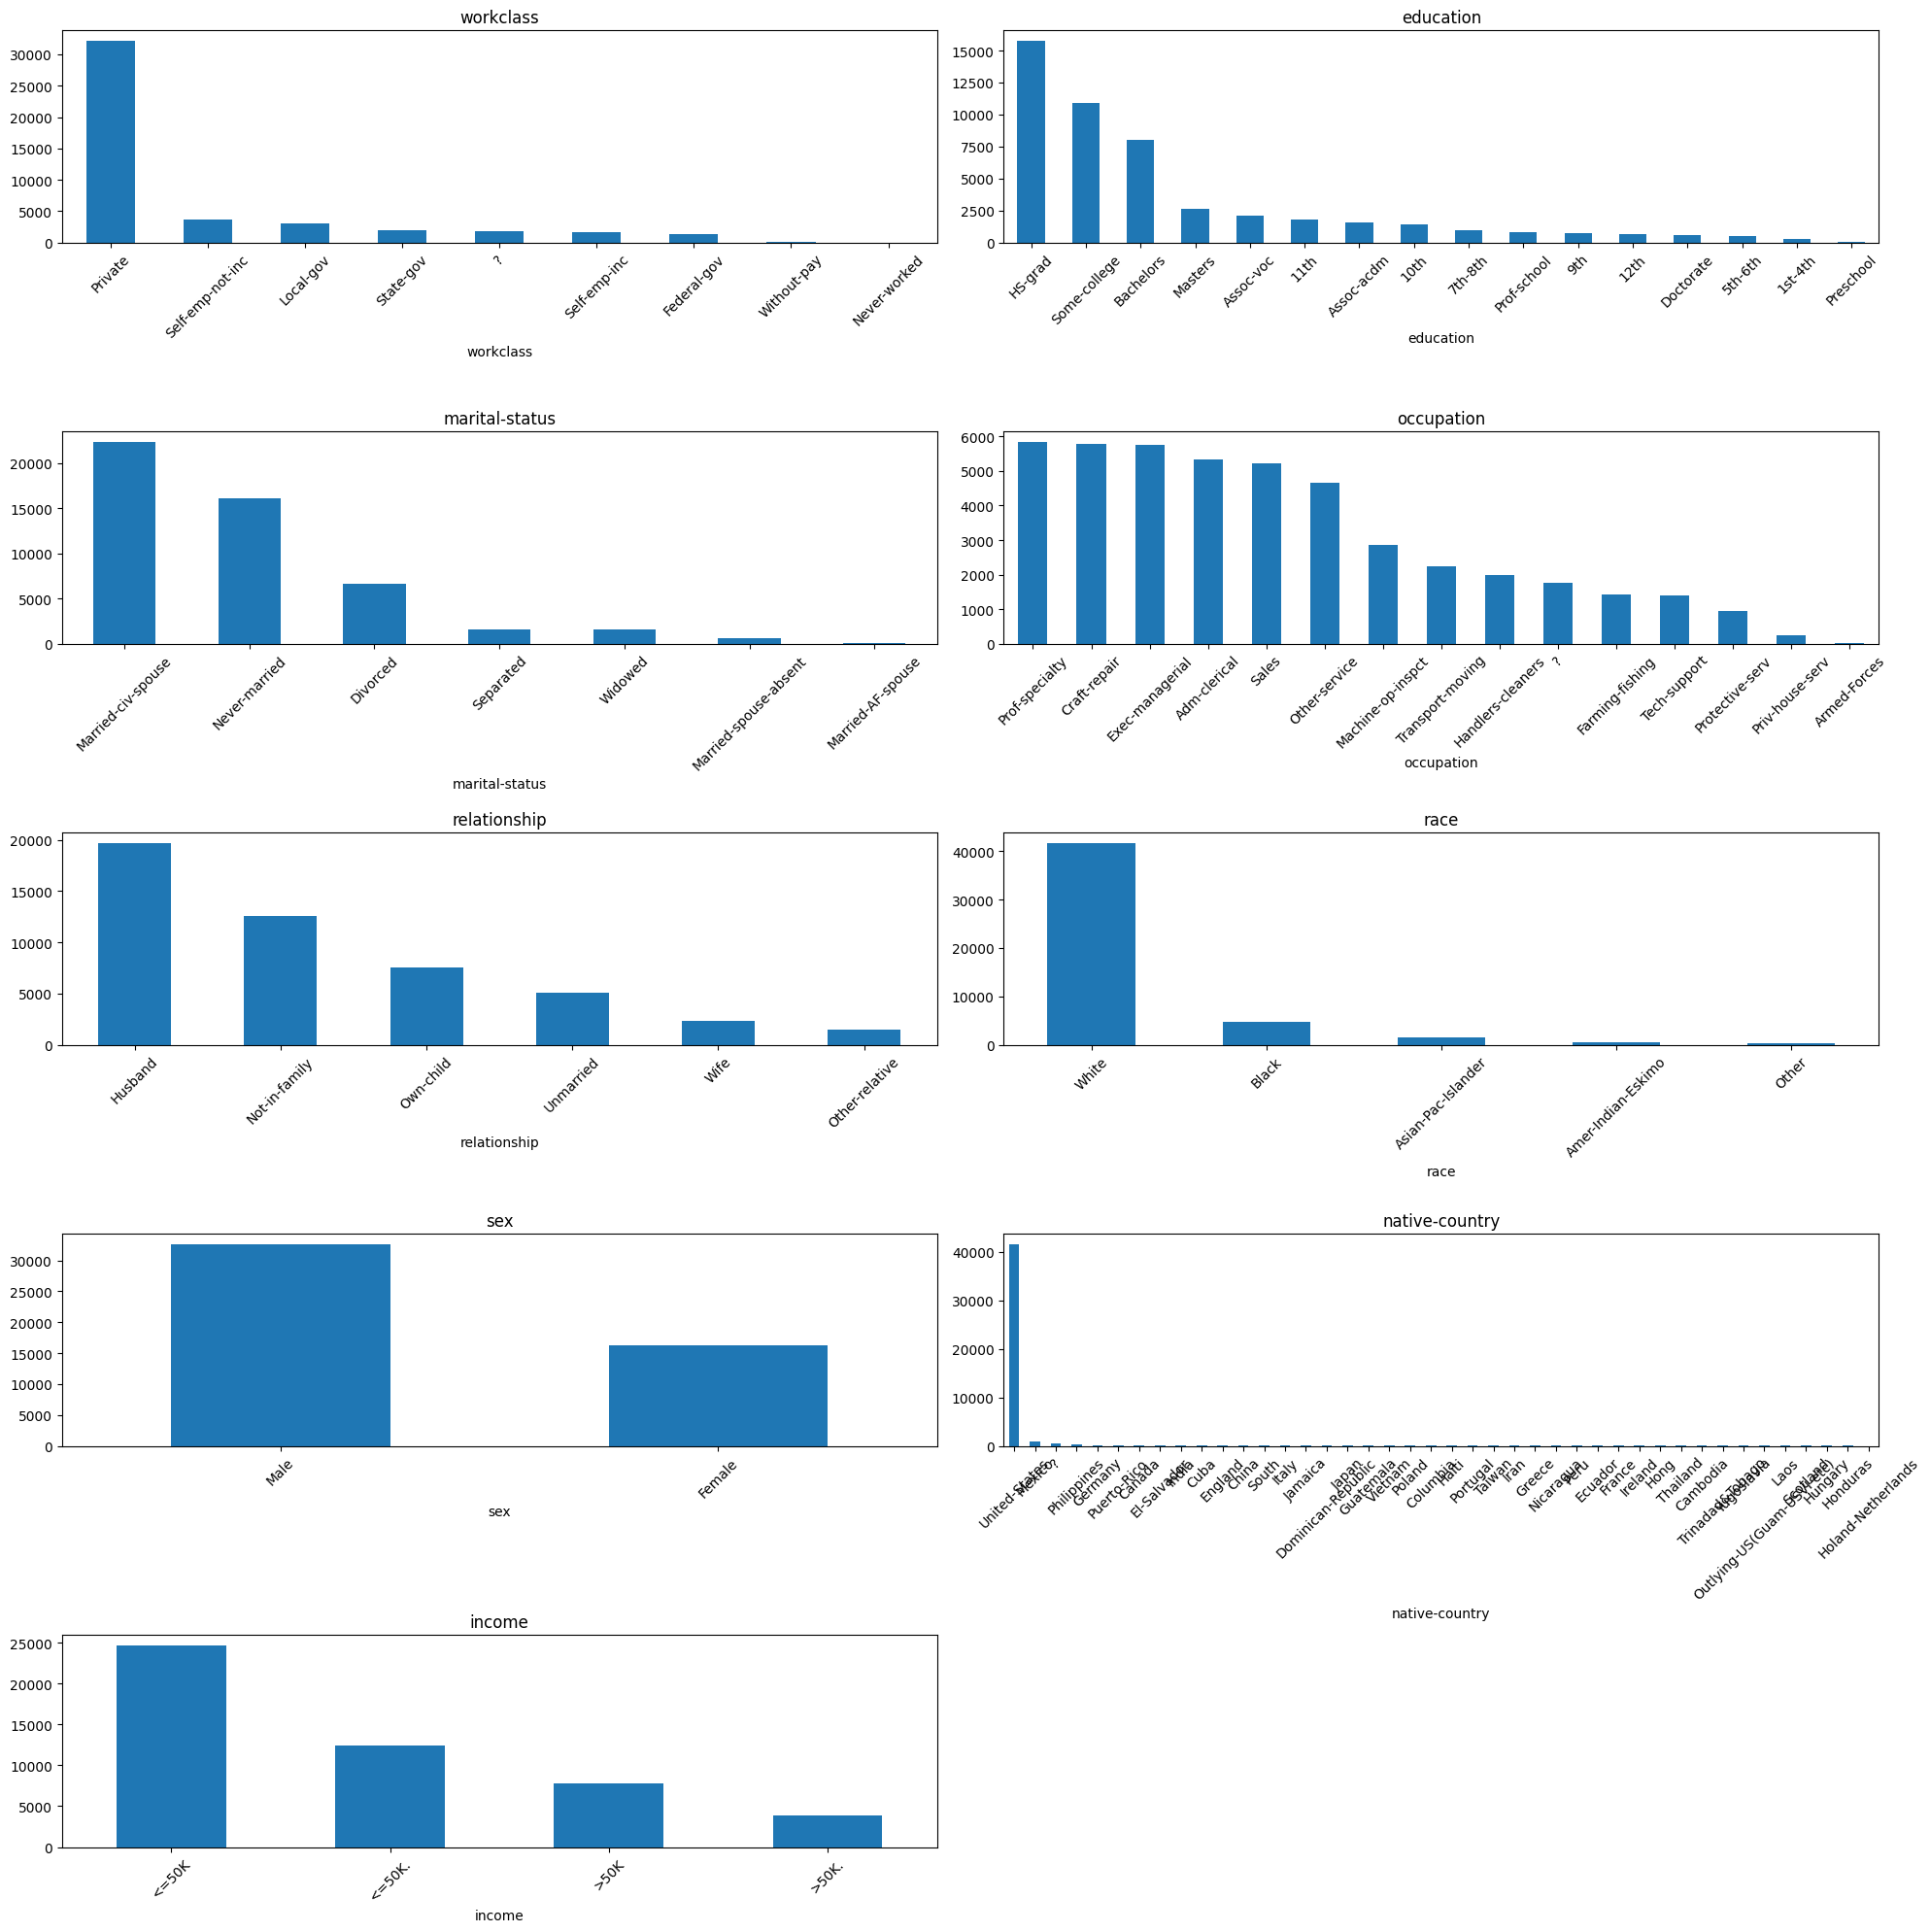

In [72]:
#for categorical data
plt.figure(figsize=(20,20))

for i, col in enumerate(adult_data_cat_cols, 1):

    plt.subplot(5, 2, i)

    adult_data[col].value_counts().plot(kind='bar')

    plt.title(col)

    plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [73]:
#Percentage of Missing Values
print((adult_data.isnull().sum()/len(adult_data))*100)

age               0.000000
workclass         6.885676
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        6.875435
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    5.540081
income            0.000000
dtype: float64


In [74]:
##from above histograms most of the values are skwed, so we can use median to replace every coulmn

In [75]:
#for workclass
adult_data['workclass'].fillna(adult_data['workclass'].mode()[0], inplace=True)

/tmp/ipykernel_1817/2251167745.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['workclass'].fillna(adult_data['workclass'].mode()[0], inplace=True)


In [76]:
#for occupation
adult_data['occupation'].fillna(adult_data['occupation'].mode()[0], inplace=True)

/tmp/ipykernel_1817/4198662577.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['occupation'].fillna(adult_data['occupation'].mode()[0], inplace=True)


In [77]:
#for native-country
adult_data['native-country'].fillna(adult_data['native-country'].mode()[0], inplace=True)

/tmp/ipykernel_1817/2073673952.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['native-country'].fillna(adult_data['native-country'].mode()[0], inplace=True)


In [78]:
#After handling missing values

adult_data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


##Handling Outliers

In [79]:
adult_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.597428,1.896605e+05,10.078278,1079.421230,87.530988,40.428481
std,13.602653,1.056025e+05,2.570759,7453.214369,403.067466,12.326046
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


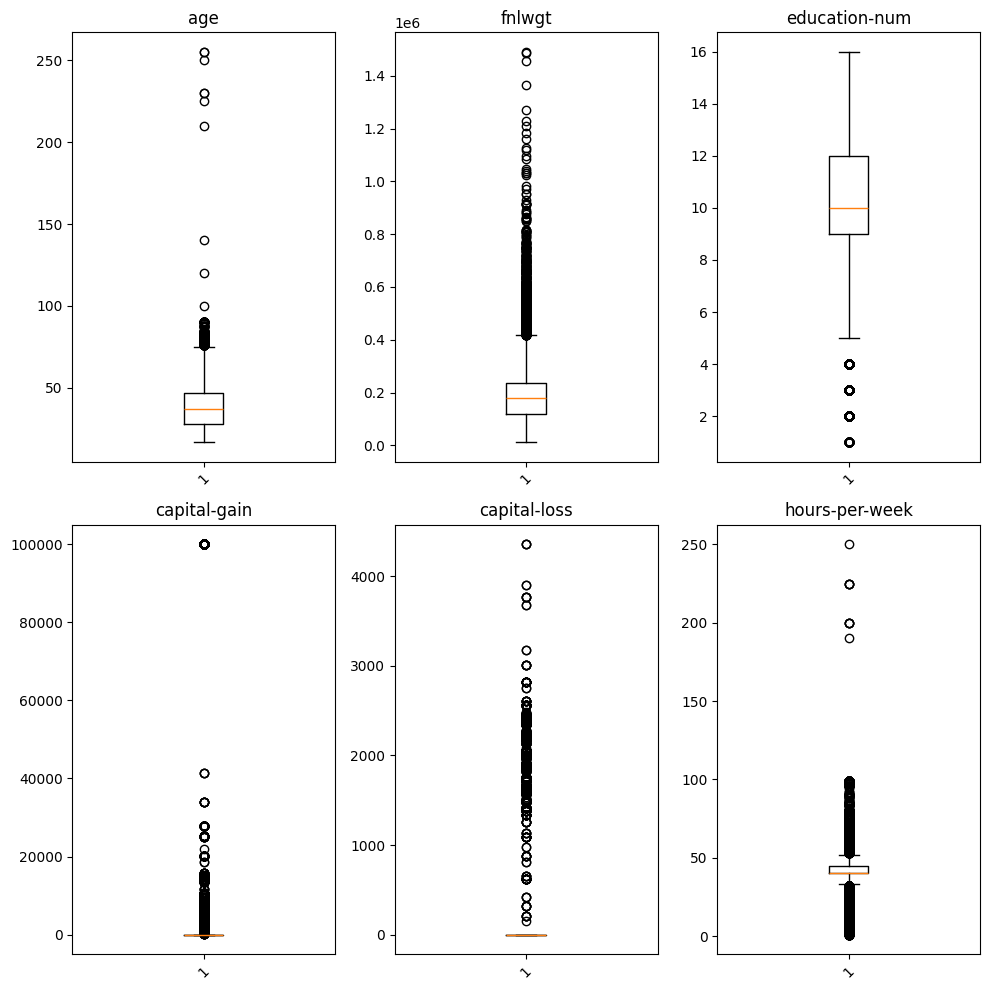

In [80]:
plt.figure(figsize=(10,10))

for i, col in enumerate(adult_data_num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(adult_data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
Q1 = adult_data[adult_data_num_cols].quantile(0.25)

Q3 = adult_data[adult_data_num_cols].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3+ (1.5 * IQR)
lower_limit = Q1- (1.5 * IQR)

outliers = ((adult_data[adult_data_num_cols] > upper_limit)|(adult_data[adult_data_num_cols] < lower_limit)).any(axis = 1)

outliers_df = adult_data[outliers]
outlier_percentage = len(outliers_df)* 100/len(adult_data)

print('percentage of outliers in the dataframe: ', outlier_percentage)

percentage of outliers in the dataframe:  40.447712284438616


This high percentage is mainly due to heavily skewed numerical features such as capital-gain, capital-loss, and fnlwgt, which naturally contain large variations and long-tailed distributions.

Instead of removing rows containing extreme values, the clip() function was used to cap values outside the acceptable range. This approach preserved the dataset size

In [82]:
outlier_cols = ["age", "fnlwgt","education-num" ]

In [83]:
adult_data[outlier_cols] = adult_data[outlier_cols].clip(lower_limit, upper_limit, axis=1)

 ###Applying Log Transformation

In [84]:

# capital-gain and capital-loss are highly right-skewed.
# Most values are 0, while a few values are extremely large.
# Log transformation reduces skewness and prevents large values
# from dominating PCA and clustering algorithms.

cols_log = ['capital-gain', 'capital-loss']

for col in cols_log:

    # log1p(x) = log(1 + x)
    # Used because log(0) is undefined

    adult_data[col] = np.log1p(adult_data[col])

# Check transformed values
print(adult_data[cols_log].head())

   capital-gain  capital-loss
0      7.684784           0.0
1      0.000000           0.0
2      0.000000           0.0
3      0.000000           0.0
4      0.000000           0.0


In [85]:
adult_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.533927,186764.026687,10.122209,0.728783,0.351088,40.428481
std,13.270067,95318.219533,2.456853,2.445845,1.586480,12.326046
min,17.000000,12285.000000,4.500000,0.000000,0.000000,1.000000
25%,28.000000,117555.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,178138.500000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,237617.000000,12.000000,0.000000,0.000000,45.000000
max,75.500000,417710.000000,16.000000,11.512925,8.379539,250.000000


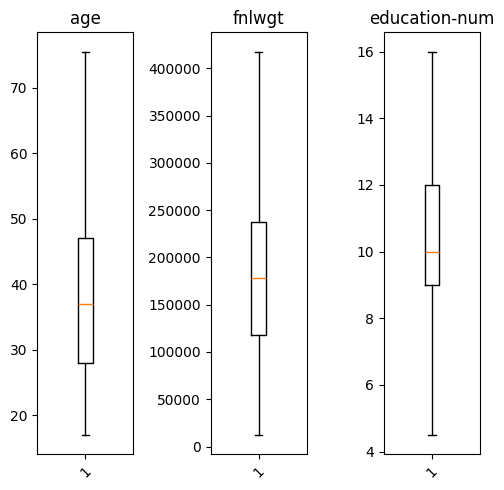

In [86]:
plt.figure(figsize=(5,5))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(adult_data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

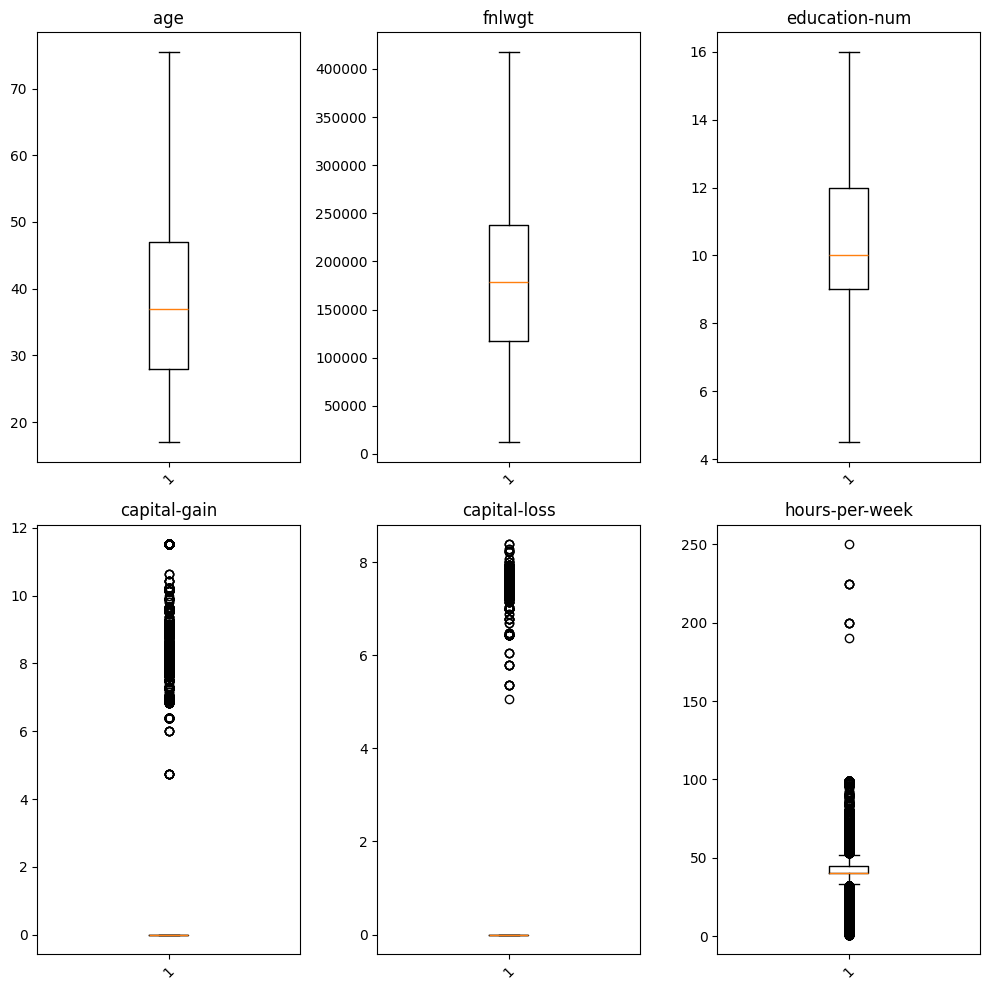

In [87]:
plt.figure(figsize=(10,10))

for i, col in enumerate(adult_data_num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(adult_data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

####Removing unwanted columns

In [88]:
#correlation
corr_matrix = adult_data[adult_data_num_cols].corr(method ='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076939,0.041684,0.121239,0.051819,0.076356
fnlwgt,-0.076939,1.000000,-0.034830,-0.007159,-0.001766,-0.011587
education-num,0.041684,-0.034830,1.000000,0.132567,0.080456,0.139905
capital-gain,0.121239,-0.007159,0.132567,1.000000,-0.065942,0.080986
capital-loss,0.051819,-0.001766,0.080456,-0.065942,1.000000,0.048157
hours-per-week,0.076356,-0.011587,0.139905,0.080986,0.048157,1.000000


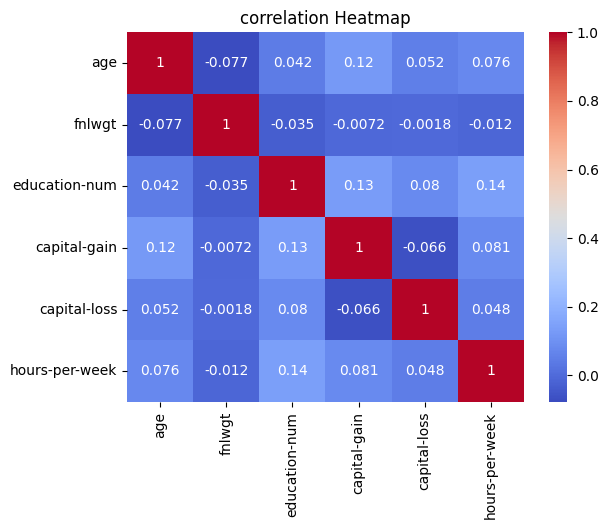

In [89]:
#plotting a heat map to visualise correlation
sns.heatmap(corr_matrix, annot=True,cmap = 'coolwarm')
plt.title("correlation Heatmap")
plt.show()

In [90]:
#Removing final wt column, because of low correlation
adult_data.drop('fnlwgt', axis = 1, inplace = True)


In [91]:
adult_data_num_cols = adult_data_num_cols.drop('fnlwgt')

In [92]:
adult_data_num_cols

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [93]:
# Both education and education_nums are essentially same  and keeping both may create redundancy
#So removing eductation column
adult_data.drop('education', axis = 1, inplace=True)

In [94]:
adult_data_cat_cols = adult_data_cat_cols.drop('education')

In [95]:
adult_data_cat_cols

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country', 'income'],
      dtype='object')

##DATA TRANSFORMATION

Since the Adult Census dataset contains skewed distributions and large numerical variations in features such as capital-gain and capital-loss, StandardScaler was considered more appropriate for preprocessing and clustering analysis.

In [96]:
standard_scaler = StandardScaler()
adult_data[adult_data_num_cols] = standard_scaler.fit_transform(
    adult_data[adult_data_num_cols])

In [97]:
adult_data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.882600e+04,4.882600e+04,4.882600e+04,4.882600e+04,4.882600e+04
mean,1.018678e-17,2.552517e-16,1.688096e-17,8.047559e-17,1.426150e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622761e+00,-2.288402e+00,-2.979709e-01,-2.213022e-01,-3.198827e+00
25%,-7.938192e-01,-4.567718e-01,-2.979709e-01,-2.213022e-01,-3.476258e-02
50%,-1.155942e-01,-4.974280e-02,-2.979709e-01,-2.213022e-01,-3.476258e-02
75%,6.379893e-01,7.643152e-01,-2.979709e-01,-2.213022e-01,3.708867e-01
max,2.785702e+00,2.392431e+00,4.409214e+00,5.060597e+00,1.700251e+01


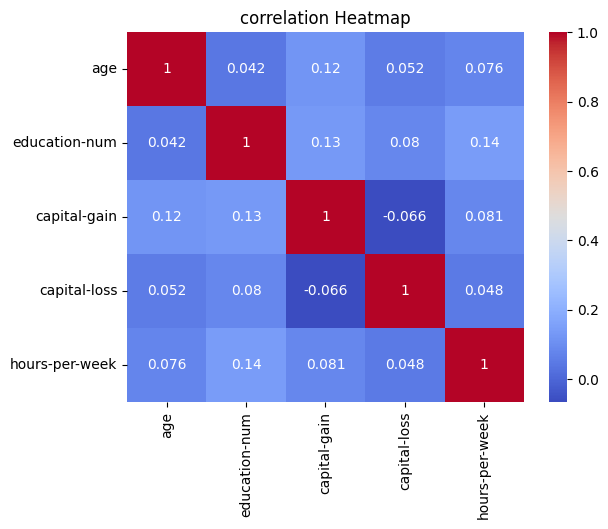

In [98]:
#correlation after scaling
corr_matrix = adult_data[adult_data_num_cols].corr(method ='pearson')
corr_matrix

sns.heatmap(corr_matrix, annot=True,cmap = 'coolwarm')
plt.title("correlation Heatmap")
plt.show()

##Encoding

In [99]:
#Before
adult_data.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.035123,State-gov,1.171344,Never-married,Adm-clerical,Not-in-family,White,Male,2.844037,-0.221302,-0.034763,United-States,<=50K
1,0.864064,Self-emp-not-inc,1.171344,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.297971,-0.221302,-2.225269,United-States,<=50K
2,-0.040236,Private,-0.456772,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.297971,-0.221302,-0.034763,United-States,<=50K
3,1.090139,Private,-1.270830,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.297971,-0.221302,-0.034763,United-States,<=50K
4,-0.793819,Private,1.171344,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.297971,-0.221302,-0.034763,Cuba,<=50K


In [100]:
adult_data_cat_cols

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country', 'income'],
      dtype='object')

In [101]:
label_encoder = LabelEncoder()
adult_data['sex'] = label_encoder.fit_transform(adult_data['sex'])

In [102]:
adult_data['marital-status'] = label_encoder.fit_transform(adult_data['marital-status'])

In [103]:
adult_data['race'] = label_encoder.fit_transform(adult_data['race'])

In [104]:
adult_data['occupation'] =label_encoder.fit_transform(adult_data['occupation'])

In [105]:
adult_data['relationship'] =label_encoder.fit_transform(adult_data['relationship'])

In [106]:
adult_data['workclass'] =label_encoder.fit_transform(adult_data['workclass'])

The income column was removed before clustering because it acts as a predefined label and clustering is an unsupervised learning technique that should identify hidden groups without target information. Additionally, the native-country feature was considered optional due to its high cardinality and heavily skewed distribution, which could introduce noise and affect clustering quality.

In [107]:
adult_data.drop(['native-country', 'income'],
                axis=1,
                inplace=True)

In [108]:
adult_data.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week
0,0.035123,7,1.171344,4,1,1,4,1,2.844037,-0.221302,-0.034763
1,0.864064,6,1.171344,2,4,0,4,1,-0.297971,-0.221302,-2.225269
2,-0.040236,4,-0.456772,0,6,1,4,1,-0.297971,-0.221302,-0.034763
3,1.090139,4,-1.270830,2,6,0,2,1,-0.297971,-0.221302,-0.034763
4,-0.793819,4,1.171344,2,10,5,2,0,-0.297971,-0.221302,-0.034763


##Dimensionality Reduction: PCA

In [109]:
X = adult_data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [110]:
# Apply PCA with 2 components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# View PCA data

print(pca_df.head())

        PC1       PC2
0 -1.171113  0.706639
1 -0.810353 -0.042558
2 -0.916041 -0.723485
3 -0.645415 -1.101455
4  2.077973  1.332972


In [111]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.18889963, 0.10928867])

Text(0, 0.5, 'Explained Variance')

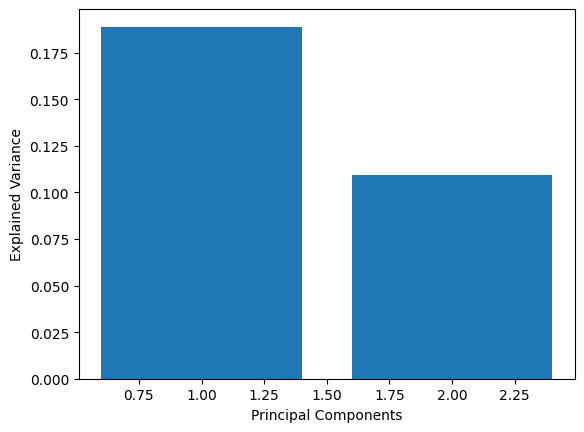

In [112]:
plt.bar(range(1, len(explained_variance)+1), explained_variance)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")

In [113]:
pca_2 = PCA(n_components = 2)
X_new_2 = pca_2.fit_transform(X)

In [114]:
exp_var = pca_2.explained_variance_ratio_

print("Percentage sum of explained variance: {}%"
      .format(np.round(np.sum(exp_var)*100, 2)))

Percentage sum of explained variance: 68.9%


In [115]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_pca)

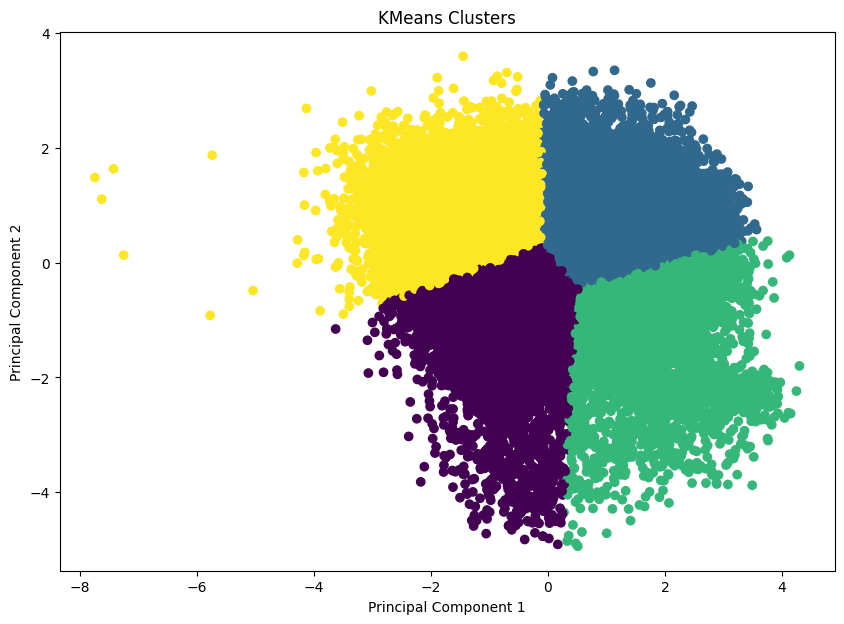

In [116]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("KMeans Clusters")

plt.show()

##CLUSTERING

In [117]:
X = adult_data

####KMean Clustering

In [118]:
wcss = []

# Finding WCSS value for different K values
for i in range(1, 11):
    k_means_model = KMeans(n_clusters=i, n_init=5)

    k_means_model.fit(X)

    # WCSS value
    wcss_value = k_means_model.inertia_

    wcss.append(wcss_value)

print(wcss)

[1435873.4918076347, 789937.1168149846, 689937.8592065071, 625536.6045463693, 576401.4293983487, 547768.1829616071, 521627.21285510156, 497319.86525720323, 476280.69333911996, 453709.31111353706]


In [119]:
#checking WCSS values
wcss

[1435873.4918076347,
 789937.1168149846,
 689937.8592065071,
 625536.6045463693,
 576401.4293983487,
 547768.1829616071,
 521627.21285510156,
 497319.86525720323,
 476280.69333911996,
 453709.31111353706]

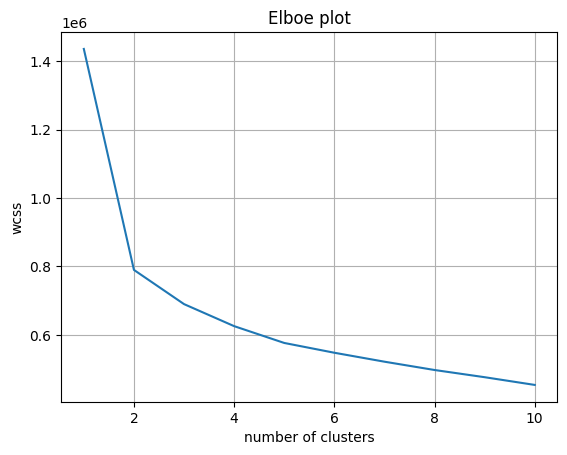

In [120]:
plt.plot(range(1,11), wcss)
plt.title("Elboe plot")
plt.xlabel("number of clusters")
plt.ylabel("wcss" )
plt.grid()
plt.show()

In [121]:
#optimum no of clusters = 6
#inference from the elbow plot

#now create a k means model with no of clusters = 6
#initialize model
k_means = KMeans(n_clusters =6, n_init=5)

#model building
k_means.fit(X)

#model prediction
cluster_label = k_means.predict(X)

cluster_label

array([5, 3, 2, ..., 4, 5, 3], dtype=int32)

In [122]:
#updating the data frame with the cluster information
adult_data["cluster"] = cluster_label

adult_data.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,cluster
0,0.035123,7,1.171344,4,1,1,4,1,2.844037,-0.221302,-0.034763,5
1,0.864064,6,1.171344,2,4,0,4,1,-0.297971,-0.221302,-2.225269,3
2,-0.040236,4,-0.456772,0,6,1,4,1,-0.297971,-0.221302,-0.034763,2
3,1.090139,4,-1.270830,2,6,0,2,1,-0.297971,-0.221302,-0.034763,2
4,-0.793819,4,1.171344,2,10,5,2,0,-0.297971,-0.221302,-0.034763,1


In [123]:
#check how many rows in each cluster
adult_data['cluster'].value_counts

<bound method IndexOpsMixin.value_counts of 0        5
1        3
2        2
3        2
4        1
        ..
48837    4
48838    1
48839    4
48840    5
48841    3
Name: cluster, Length: 48826, dtype: int32>

##Silhouette Score

In [124]:
# Take sample data
sample_data = X_scaled[:5000]

# Train model
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

labels = kmeans.fit_predict(sample_data)

# Calculate score
score = silhouette_score(
    sample_data,
    labels
)

print(score)

0.14898289962703723


####Agglomerative clustering

In [125]:
# Use sample data
sample_data = X_pca[:3000]

# Build model
agglo = AgglomerativeClustering(
    n_clusters=6
)

# Fit model
agglo_labels = agglo.fit_predict(sample_data)

In [126]:
sample_pca_df = pd.DataFrame(
    sample_data,
    columns=['PC1', 'PC2']
)

In [127]:
sample_pca_df['Agglo_Cluster'] = agglo_labels

##Visualizing clusters



###Visualize KMeans Clusters


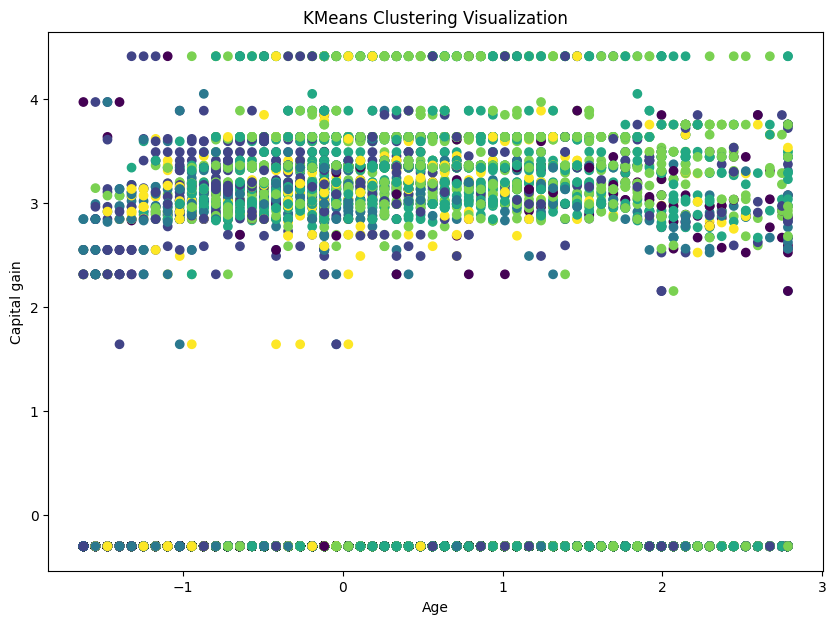

In [128]:
plt.figure(figsize=(10,7))

plt.scatter(
    adult_data['age'],
    adult_data['capital-gain'],
    c=adult_data['cluster']
)

plt.xlabel("Age")

plt.ylabel("Capital gain")

plt.title("KMeans Clustering Visualization")

plt.show()

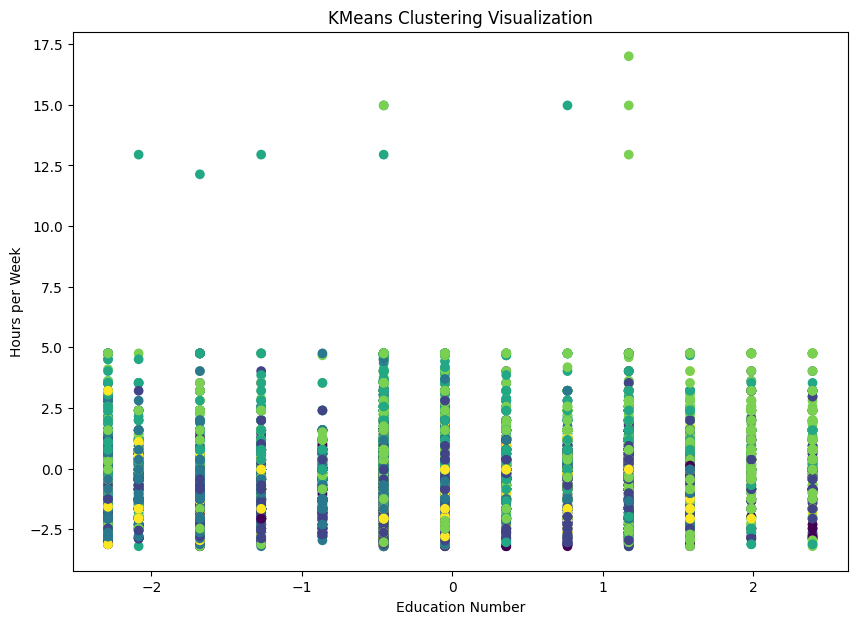

In [129]:
plt.figure(figsize=(10,7))

plt.scatter(
    adult_data['education-num'],
    adult_data['hours-per-week'],
    c=adult_data['cluster']
)

plt.xlabel("Education Number")

plt.ylabel("Hours per Week")

plt.title("KMeans Clustering Visualization")

plt.show()

###Visualize Agglomerative Clusters

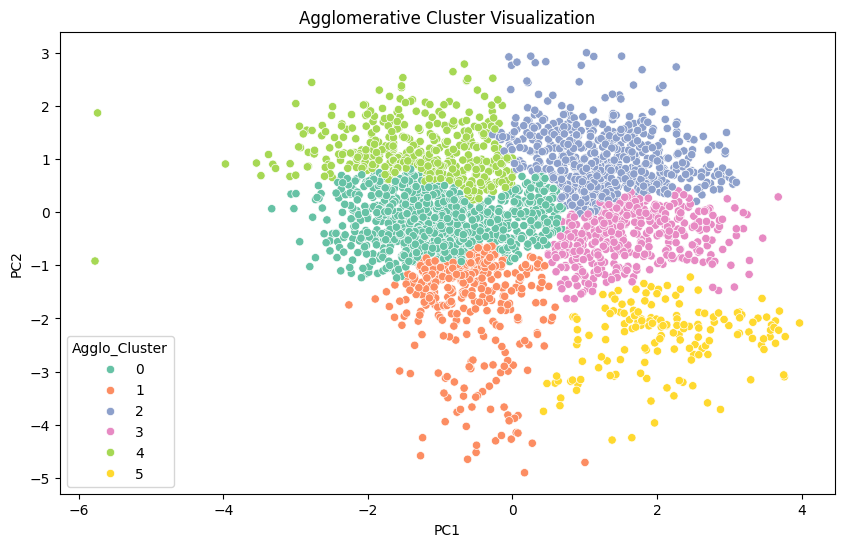

In [130]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Agglo_Cluster',
    palette='Set2',
    data=sample_pca_df
)

plt.title("Agglomerative Cluster Visualization")

plt.show()

###Cluster Profiling

###KMeans Cluster Count

In [131]:
adult_data.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'cluster'],
      dtype='object')

In [132]:
adult_data['cluster'].value_counts()

,count
cluster,
3,11278
4,10332
2,9869
1,8749
5,6166
0,2432


###Cluster Mean Analysis


In [133]:
adult_data.groupby('cluster').mean()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week
cluster,,,,,,,,,,,
0,0.184104,0.420641,-0.238362,2.874178,0.365132,1.829770,3.548931,0.527138,-0.067728,-0.051925,-0.497490
1,-0.420171,3.958967,0.243352,3.648303,11.112927,2.550577,3.597211,0.411704,-0.090455,-0.038392,-0.264651
2,-0.260385,4.047016,-0.598731,2.961901,7.241159,1.867565,3.542912,0.621137,-0.161883,-0.105468,-0.266249
3,0.301646,4.314861,0.061145,2.005852,3.423302,0.289768,3.811403,0.897854,0.125475,0.073095,0.340968
4,0.413373,4.158343,0.382617,1.679926,11.420248,0.289199,3.769067,0.912505,0.178163,0.110174,0.336344
5,-0.304063,4.161044,-0.045947,3.200454,2.040221,3.084820,3.584009,0.336199,-0.113877,-0.074546,-0.189365


Cluster 0

Medium education
Average working hours
Moderate income

Cluster 1

Higher education
Higher capital gain
Likely higher income group

Cluster 2

Lower working hours
Lower education
Financial aid programs recommended

Cluster 3

High work hours
Stable employment

Cluster 4

Senior age population
Retirement planning useful

Cluster 5

Young workforce
Skill development programs beneficial

###Business Insights

In [134]:
print("\n================ BUSINESS INSIGHTS ================\n")

print("1. Education level strongly impacts socioeconomic grouping.")

print("2. Capital gain separates affluent and non-affluent populations.")

print("3. Working hours influence employment-based clustering.")

print("4. Hidden socioeconomic segments exist beyond simple income labels.")

print("5. PCA helped reduce dimensional complexity for visualization.")



================ BUSINESS INSIGHTS ================

1. Education level strongly impacts socioeconomic grouping.
2. Capital gain separates affluent and non-affluent populations.
3. Working hours influence employment-based clustering.
4. Hidden socioeconomic segments exist beyond simple income labels.
5. PCA helped reduce dimensional complexity for visualization.


 ###Policy Recommendations

In [135]:
print("\n================ POLICY RECOMMENDATIONS ================\n")

print("1. Provide skill development programs for low-income clusters.")

print("2. Launch financial literacy campaigns for vulnerable groups.")

print("3. Create employment assistance programs.")

print("4. Introduce targeted tax and investment planning initiatives.")

print("5. Support welfare and inclusion programs for economically weaker segments.")


================ POLICY RECOMMENDATIONS ================

1. Provide skill development programs for low-income clusters.
2. Launch financial literacy campaigns for vulnerable groups.
3. Create employment assistance programs.
4. Introduce targeted tax and investment planning initiatives.
5. Support welfare and inclusion programs for economically weaker segments.
